# Phase 2: Unsupervised Learning

In this phase, we apply clustering techniques to discover hidden patterns in the dataset and enhance the prediction system.

# Data Preparation

We used the preprocessed dataset from Phase 1.  
The target variable (`NObeyesdad_encoded`) was removed before clustering because unsupervised learning should not use class labels during training.  
The dataset had already been cleaned and normalized in Phase 1, making it suitable for clustering analysis.

In [2]:
import pandas as pd

df = pd.read_csv("preprocessed_data.csv")
df.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded,NObeyesdad_encoded
0,0.148936,0.5,0.666667,0.5,0.000000,0.5,0.301162,0,1,0,2,0,0,3,3,1
1,0.148936,1.0,0.666667,1.0,1.000000,0.0,0.297240,0,1,0,2,1,1,2,3,1
2,0.191489,0.5,0.666667,0.5,0.666667,0.5,0.284736,1,1,0,2,0,0,1,3,1
3,0.276596,1.0,0.666667,0.5,0.666667,0.0,0.366359,1,0,0,2,0,0,1,4,5
4,0.170213,0.5,0.000000,0.5,0.000000,0.0,0.405778,1,0,0,2,0,0,2,3,6


In [3]:
X = df.drop("NObeyesdad_encoded", axis=1)

# Clustering Rationale & Algorithm Selection
We selected K-Means because it is efficient for numerical data and works well when clusters are relatively compact.
We selected Hierarchical Clustering to compare a second clustering approach that does not rely on centroid-based assignment and can reveal nested grouping structure.
These algorithms were chosen based on dataset size, numerical feature representation, interpretability, and suitability for comparing different clustering behaviors.

# Cluster Determination

To determine the optimal number of clusters, we tested several values of k using the Elbow Method and Silhouette Score.  
Based on the results, **k = 5** was selected as the most appropriate number of clusters because it provided a good balance between cluster compactness and separation.

# Elbow Method

We used the Elbow Method to determine the optimal number of clusters.

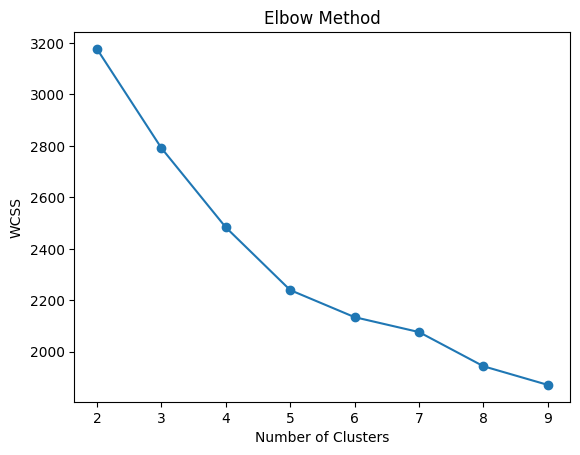

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Silhouette Score Evaluation

We evaluated the clustering performance using the Silhouette Score to determine the best number of clusters.

In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_4 = kmeans.fit_predict(X)

In [22]:
from sklearn.metrics import silhouette_score

score_4 = silhouette_score(X, clusters_4)
print("Silhouette Score for k=4:", score_4)

Silhouette Score for k=4: 0.28058444802462207


In [9]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters_5 = kmeans.fit_predict(X)

In [10]:
score_5 = silhouette_score(X, clusters_5)
print("Silhouette Score for k=5:", score_5)

Silhouette Score for k=5: 0.2954091716380449


# K-Means Clustering

We applied K-Means clustering to group similar individuals based on lifestyle and health features using the selected value of k = 5.

In [20]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters_kmeans = kmeans.fit_predict(X)
df["cluster"] = clusters_kmeans

In [23]:
df.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded,NObeyesdad_encoded,cluster,cluster_hc
0,0.148936,0.5,0.666667,0.5,0.000000,0.5,0.301162,0,1,0,2,0,0,3,3,1,4,0
1,0.148936,1.0,0.666667,1.0,1.000000,0.0,0.297240,0,1,0,2,1,1,2,3,1,3,0
2,0.191489,0.5,0.666667,0.5,0.666667,0.5,0.284736,1,1,0,2,0,0,1,3,1,1,3
3,0.276596,1.0,0.666667,0.5,0.666667,0.0,0.366359,1,0,0,2,0,0,1,4,5,1,3
4,0.170213,0.5,0.000000,0.5,0.000000,0.0,0.405778,1,0,0,2,0,0,2,3,6,1,0


# Cluster Interpretation & Profiles

To understand the characteristics of each cluster, we examined the mean feature values within each cluster.  
We also compared cluster assignments with the original obesity labels for external interpretation only.  
The target variable was not used during clustering and was only used afterward to understand the composition of each cluster.


In [24]:
df.groupby("cluster").mean()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded,NObeyesdad_encoded,cluster_hc
cluster,,,,,,,,,,,,,,,,,
0,0.372927,0.676210,0.589245,0.480591,0.343010,0.233536,0.426793,0.641469,0.887689,0.911447,1.898488,0.023758,0.030238,2.280778,0.015119,3.161987,0.993521
1,0.191318,0.621483,0.591343,0.562690,0.357387,0.323013,0.427751,1.000000,0.881391,0.922290,1.991820,0.036810,0.014315,1.959100,3.038855,3.437628,2.439673
2,0.156853,0.747116,0.608532,0.380596,0.362502,0.348878,0.195793,0.281250,0.482143,0.705357,0.821429,0.026786,0.107143,2.428571,3.040179,0.906250,1.906250
3,0.177644,0.853501,0.598409,0.540389,0.275163,0.359004,0.581307,0.000000,0.825279,0.944238,2.013011,0.013011,0.050186,1.972119,3.007435,3.490706,3.072491
4,0.168348,0.642821,0.437564,0.468643,0.380068,0.414220,0.434426,0.544236,0.879357,0.817694,2.008043,0.005362,0.064343,3.000000,3.032172,2.855228,0.021448


In [25]:
pd.crosstab(df["cluster"], df["NObeyesdad_encoded"])

NObeyesdad_encoded,0,1,2,3,4,5,6
cluster,,,,,,,
0,46,48,110,96,1,68,94
1,35,60,55,143,1,92,103
2,117,79,6,2,0,14,6
3,52,38,33,1,322,69,23
4,17,57,147,55,0,33,64


## Cluster Profile Interpretation

Cluster 0 represents a mixed group with moderate distribution across obesity classes. It contains individuals from multiple categories, suggesting an average lifestyle pattern without strong extremes.

Cluster 1 shows a higher concentration in obesity levels 2 and 3, indicating a group with elevated obesity risk and potentially less healthy lifestyle habits.

Cluster 2 is dominated by normal weight and lower obesity classes, suggesting a low-risk group with healthier lifestyle patterns.

Cluster 3 is heavily concentrated in obesity level 4, indicating the highest-risk group with severe obesity characteristics.

Cluster 4 contains a higher number of individuals in obesity level 2, suggesting a moderately high-risk group, but less severe than Cluster 3.

Overall, the clusters reveal clear segmentation of individuals based on obesity risk levels, which supports the use of clustering to enhance personalized health recommendations.

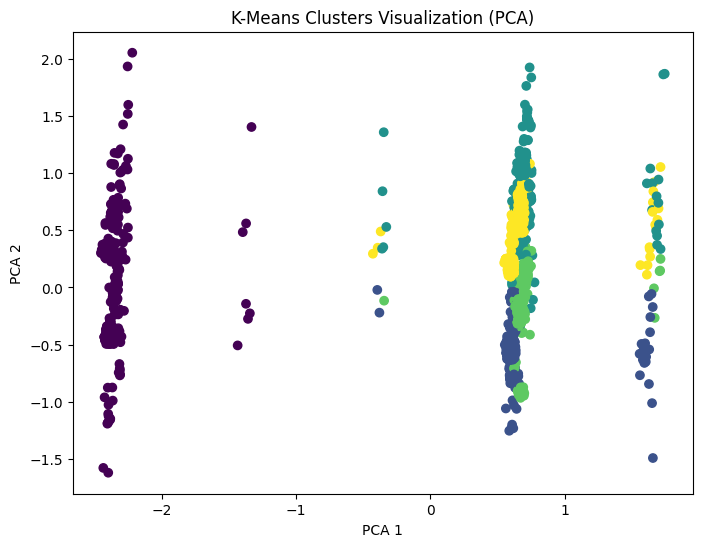

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans)
plt.title("K-Means Clusters Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

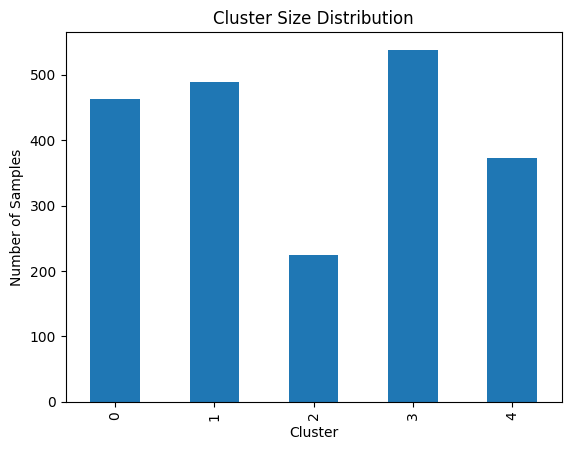

In [27]:
df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.show()

# Hierarchical Clustering

We applied Agglomerative (Hierarchical) Clustering as a second algorithm to compare results with K-Means.

In [28]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)
clusters_hc = hc.fit_predict(X)

df["cluster_hc"] = clusters_hc

In [29]:
score_hc = silhouette_score(X, clusters_hc)
print("Silhouette Score (Hierarchical):", score_hc)

Silhouette Score (Hierarchical): 0.24895543664640118


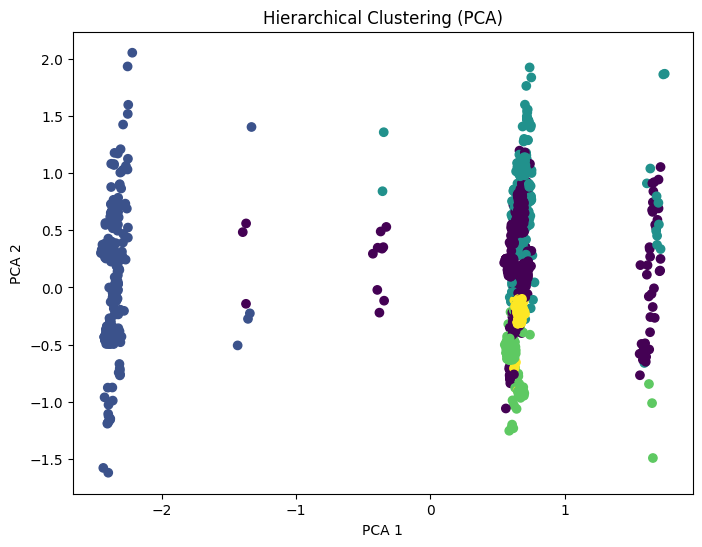

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_hc)
plt.title("Hierarchical Clustering (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

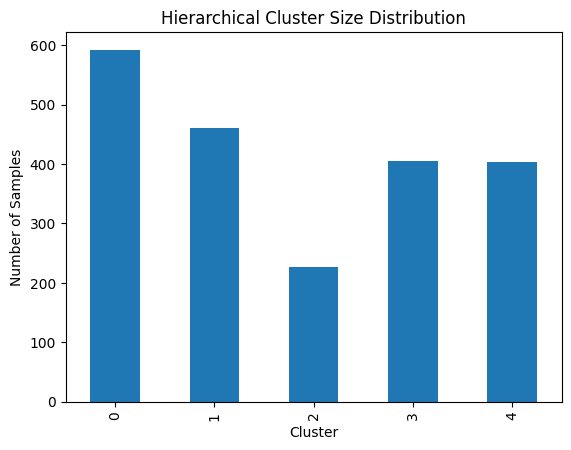

In [31]:
df["cluster_hc"].value_counts().sort_index().plot(kind="bar")
plt.title("Hierarchical Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.show()

# Davies-Bouldin Index

We used the Davies-Bouldin Index to evaluate clustering performance. Lower values indicate better cluster separation.

In [33]:
from sklearn.metrics import davies_bouldin_score

print("Davies-Bouldin (KMeans):", davies_bouldin_score(X, clusters_kmeans))
print("Davies-Bouldin (Hierarchical):", davies_bouldin_score(X, clusters_hc))

Davies-Bouldin (KMeans): 1.403743370222091
Davies-Bouldin (Hierarchical): 1.7045654533051806


# Model Comparison

K-Means achieved better clustering quality than Hierarchical Clustering based on the evaluation metrics.  
It produced a higher Silhouette Score and a lower Davies-Bouldin Index, indicating better cluster compactness and separation.  
In addition, K-Means provided clearer and more interpretable groups in the PCA visualization.  

Therefore, K-Means was selected as the final clustering method for this project.

# Integration Strategy

The clustering results can be integrated with the supervised model by first assigning each user to a cluster, then applying the classification model to predict the obesity level.

This allows the system to provide more personalized and context-aware recommendations based on both the predicted class and the user’s cluster profile.

# Challenges & Limitations

Some clusters may overlap due to similarities in lifestyle patterns among individuals.  
Additionally, PCA visualization reduces dimensionality, which may not fully represent all feature relationships.  
Another limitation is that clustering results can vary depending on the selected number of clusters and the algorithm used.

# Conclusion

Based on the evaluation metrics and visualizations, K-Means was the most suitable clustering algorithm for this dataset.  
The clustering results revealed meaningful groups that can be used to enhance the final obesity advice system with more personalized recommendations.